<a href="https://colab.research.google.com/github/eshanikane/MLCS_Exp2/blob/main/MLCS_Exp3_%26_Exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exp3


In [ ]:
!pip install pandas requests


In [1]:
import requests
import pandas as pd
import time
import random
from datetime import datetime

dataset = []

def fetch_live_data():
    url = "https://openphish.com/feed.txt"
    response = requests.get(url)

    if response.status_code == 200:
        return response.text.split("\n")[:20]
    else:
        return []

print("Starting real-time data collection...")

for cycle in range(10):

    print(f"Cycle {cycle+1} collecting...")

    urls = fetch_live_data()

    for u in urls:
        if u.strip() == "":
            continue

        record = {
            "timestamp": datetime.now(),
            "source_ip": f"192.168.1.{random.randint(1,255)}",
            "request_length": len(u),
            "failed_login_attempts": random.randint(0,3),
            "api_request_frequency": random.randint(1,10),
            "geo_location": random.choice(["IN","US","UK","SG","DE"]),
            "resource_access_count": random.randint(1,20)
        }

        dataset.append(record)


    time.sleep(5)

print("Data collection completed.")


Starting real-time data collection...
Cycle 1 collecting...
Cycle 2 collecting...
Cycle 3 collecting...
Cycle 4 collecting...
Cycle 5 collecting...
Cycle 6 collecting...
Cycle 7 collecting...
Cycle 8 collecting...
Cycle 9 collecting...
Cycle 10 collecting...
Data collection completed.


In [2]:
df = pd.DataFrame(dataset)

print("Dataset Preview:")
print(df.head())

df.to_csv("cloud_security_realtime_logs.csv", index=False)

print("Dataset saved successfully!")


Dataset Preview:
                   timestamp      source_ip  request_length  \
0 2026-03-06 03:47:12.329057  192.168.1.167              27   
1 2026-03-06 03:47:12.329111  192.168.1.149              43   
2 2026-03-06 03:47:12.329127  192.168.1.165              87   
3 2026-03-06 03:47:12.329137   192.168.1.46              65   
4 2026-03-06 03:47:12.329147  192.168.1.125             120   

   failed_login_attempts  api_request_frequency geo_location  \
0                      1                      7           US   
1                      1                      2           SG   
2                      3                      7           SG   
3                      1                      8           SG   
4                      2                      1           US   

   resource_access_count  
0                     19  
1                      4  
2                      4  
3                     10  
4                     11  
Dataset saved successfully!


In [3]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Data cleaned.")


Data cleaned.


# Exp4


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv("/content/cloud_security_realtime_logs.csv")

print(df.head())


                    timestamp      source_ip  request_length  \
0  2026-03-06 03:47:12.329057  192.168.1.167              27   
1  2026-03-06 03:47:12.329111  192.168.1.149              43   
2  2026-03-06 03:47:12.329127  192.168.1.165              87   
3  2026-03-06 03:47:12.329137   192.168.1.46              65   
4  2026-03-06 03:47:12.329147  192.168.1.125             120   

   failed_login_attempts  api_request_frequency geo_location  \
0                      1                      7           US   
1                      1                      2           SG   
2                      3                      7           SG   
3                      1                      8           SG   
4                      2                      1           US   

   resource_access_count  
0                     19  
1                      4  
2                      4  
3                     10  
4                     11  


In [5]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print("After cleaning:", df.shape)

After cleaning: (200, 7)


In [6]:
features = [
    "request_length",
    "failed_login_attempts",
    "api_request_frequency",
    "resource_access_count",
]

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])


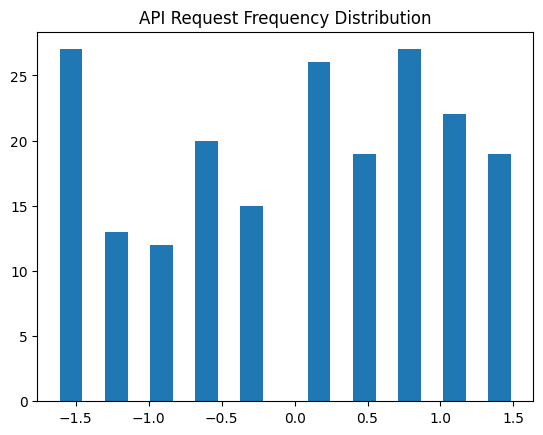

In [7]:
plt.hist(df["api_request_frequency"], bins=20)
plt.title("API Request Frequency Distribution")
plt.show()


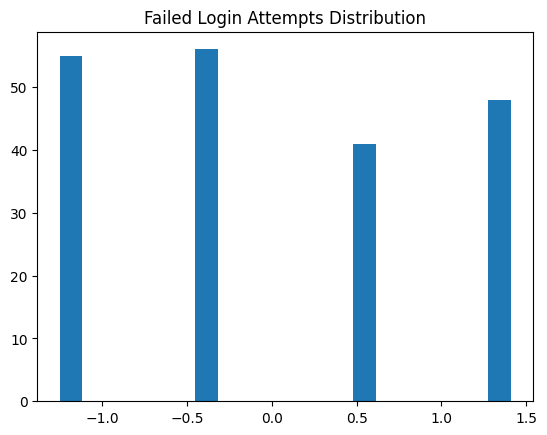

In [8]:
plt.hist(df["failed_login_attempts"], bins=20)
plt.title("Failed Login Attempts Distribution")
plt.show()


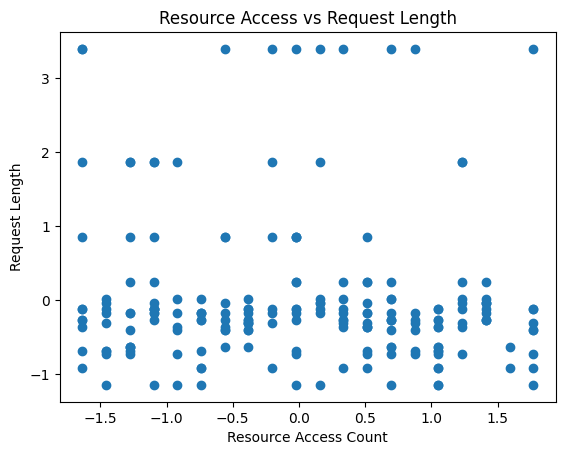

In [9]:
plt.scatter(df["resource_access_count"], df["request_length"])
plt.title("Resource Access vs Request Length")
plt.xlabel("Resource Access Count")
plt.ylabel("Request Length")
plt.show()
